# Benchmark analysis

Loads the CSVs produced by `python scripts/run_benchmark.py` and visualizes the
algorithm comparison: search effort, runtime, route quality per preference
profile, and Pareto fronts.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

results = Path("results") if Path("results/benchmark_single.csv").exists() else Path("../results")
single = pd.read_csv(results / "benchmark_single.csv")
multi = pd.read_csv(results / "benchmark_multi.csv")
pareto = pd.read_csv(results / "benchmark_pareto.csv")
single.head()

,pair,source,target,od_km,profile,algorithm,found,runtime_ms,visited_nodes,length_m,total_cost,pen_travel,pen_congestion,pen_sinuosity,pen_elevation,pen_road_type,pen_scenic
0,0,9347267481,2800804865,2.6763,shortest,dijkstra,True,0.8120,255,3424.69,3424.6875,901.3425,2560.0690,2.4806,45.9012,976.7786,3424.6875
1,0,9347267481,2800804865,2.6763,shortest,astar,True,0.3967,74,3424.69,3424.6875,901.3425,2560.0690,2.4806,45.9012,976.7786,3424.6875
2,1,1151993334,1955609259,2.1922,shortest,dijkstra,True,4.8894,1453,3405.77,3405.7723,1504.4725,1309.6032,3.2931,38.2510,230.8071,1007.2536
3,1,1151993334,1955609259,2.1922,shortest,astar,True,1.2349,296,3405.77,3405.7723,1504.4725,1309.6032,3.2931,38.2510,230.8071,1007.2536
4,2,2718266278,4959787537,1.0111,shortest,dijkstra,True,1.4145,449,2534.00,2533.9962,762.0441,1507.5981,0.8701,30.6008,465.8053,483.8033


## Dijkstra vs A\*: search effort and runtime

A\* should expand far fewer nodes than Dijkstra for the same optimal cost.

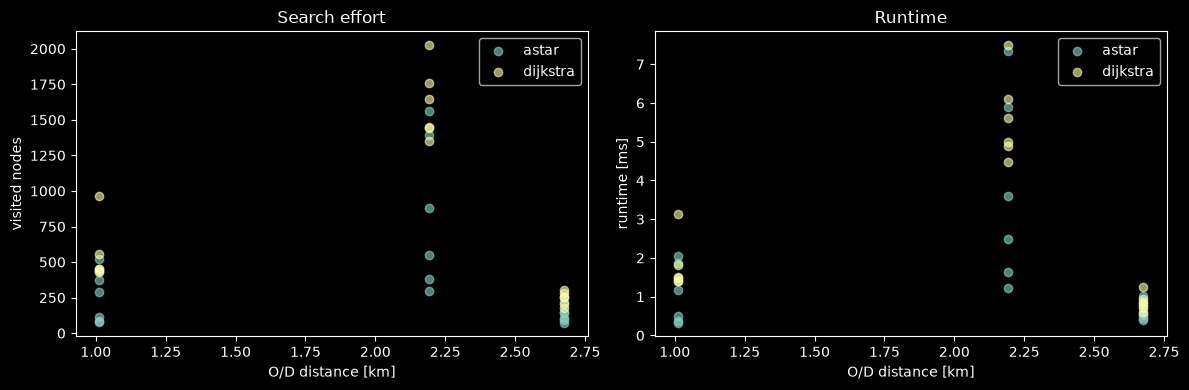

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for name, grp in single.groupby("algorithm"):
    ax[0].scatter(grp["od_km"], grp["visited_nodes"], label=name, alpha=0.6)
    ax[1].scatter(grp["od_km"], grp["runtime_ms"], label=name, alpha=0.6)
ax[0].set(xlabel="O/D distance [km]", ylabel="visited nodes", title="Search effort")
ax[1].set(xlabel="O/D distance [km]", ylabel="runtime [ms]", title="Runtime")
ax[0].legend()
ax[1].legend()
plt.tight_layout()
plt.show()

In [3]:
single.groupby("algorithm")[["visited_nodes", "runtime_ms"]].mean()

,visited_nodes,runtime_ms
algorithm,,
astar,405.333333,1.787378
dijkstra,801.722222,2.751911


## Route quality per preference profile

How the chosen route changes with the weight configuration (Dijkstra rows).

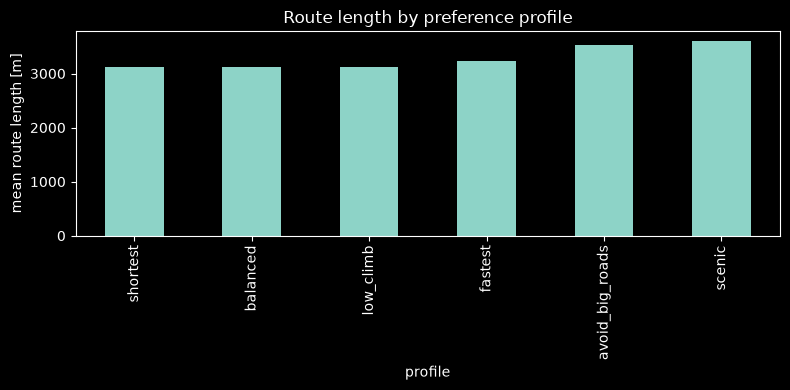

In [4]:
d = single[single["algorithm"] == "dijkstra"]
ax = d.groupby("profile")["length_m"].mean().sort_values().plot.bar(figsize=(8, 4))
ax.set(ylabel="mean route length [m]", title="Route length by preference profile")
plt.tight_layout()
plt.show()

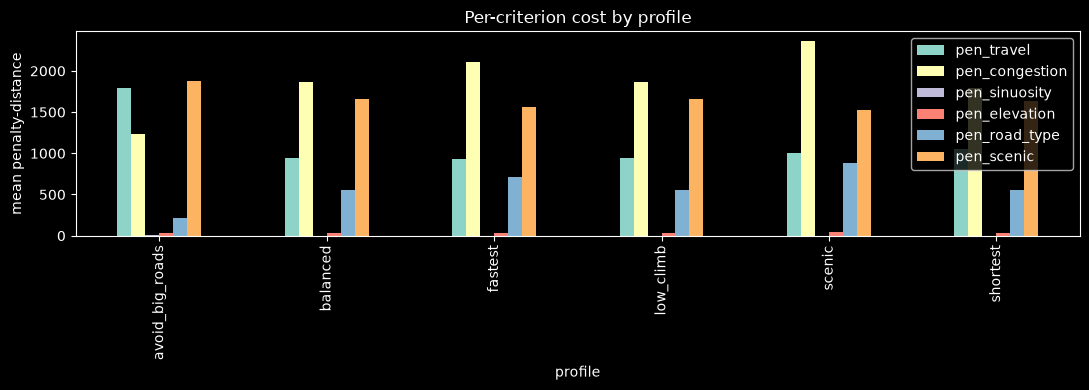

,pen_travel,pen_congestion,pen_sinuosity,pen_elevation,pen_road_type,pen_scenic
profile,,,,,,
avoid_big_roads,1789.528100,1228.536267,4.131533,38.615300,215.707767,1872.863667
balanced,948.624133,1866.005033,1.218967,36.793800,560.590833,1655.137100
fastest,925.026400,2109.861133,1.160533,37.158100,709.849200,1567.268133
low_climb,948.624133,1866.005033,1.218967,36.793800,560.590833,1655.137100
scenic,1003.092967,2362.050167,1.478567,43.351133,881.627067,1530.083300
shortest,1055.953033,1792.423433,2.214600,38.251000,557.797000,1638.581467


In [5]:
pen_cols = [c for c in single.columns if c.startswith("pen_")]
means = single[single["algorithm"] == "dijkstra"].groupby("profile")[pen_cols].mean()
means.plot.bar(figsize=(11, 4))
plt.ylabel("mean penalty-distance")
plt.title("Per-criterion cost by profile")
plt.tight_layout()
plt.show()
means

## Multi-objective: MO-Dijkstra vs NAMOA\*

Same Pareto front; compare runtime and how the front size grows with distance.

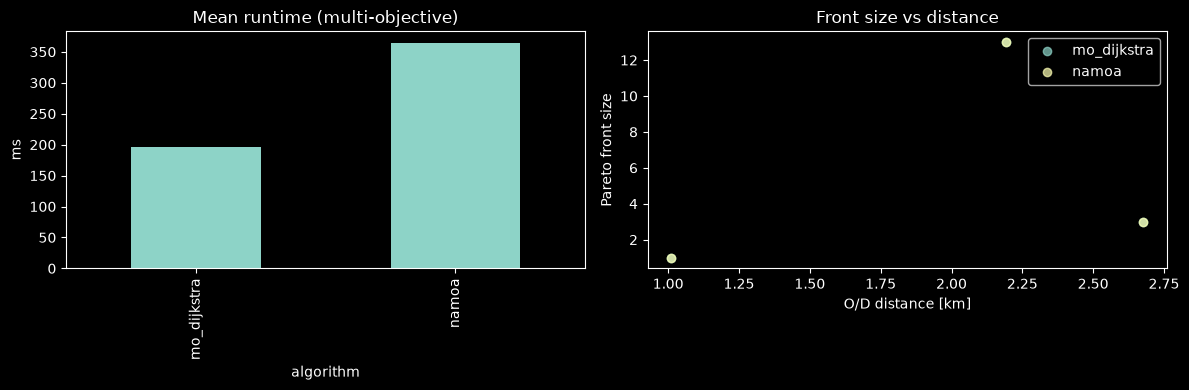

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
multi.groupby("algorithm")["runtime_ms"].mean().plot.bar(ax=ax[0], title="Mean runtime (multi-objective)")
ax[0].set_ylabel("ms")
for name, grp in multi.groupby("algorithm"):
    ax[1].scatter(grp["od_km"], grp["front_size"], label=name, alpha=0.7)
ax[1].set(xlabel="O/D distance [km]", ylabel="Pareto front size", title="Front size vs distance")
ax[1].legend()
plt.tight_layout()
plt.show()

## A Pareto front

The trade-off between the first two objectives for the pair with the largest front.

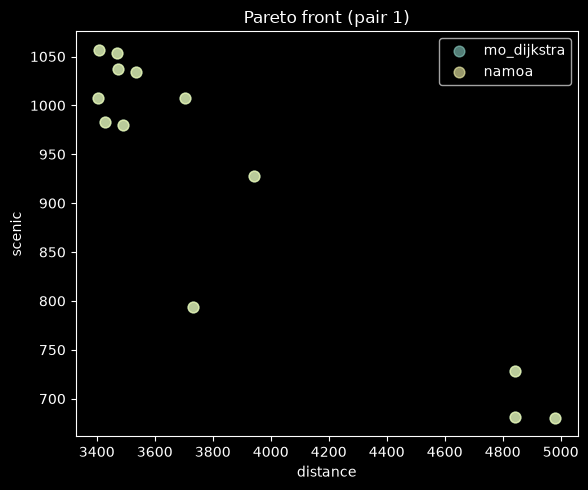

In [7]:
axis_cols = [c for c in pareto.columns if c not in ("pair", "algorithm", "route_index", "n_nodes")]
best_pair = pareto.groupby("pair")["route_index"].max().idxmax()
sub = pareto[pareto["pair"] == best_pair]
x, y = axis_cols[0], axis_cols[1]
fig, ax = plt.subplots(figsize=(6, 5))
for name, grp in sub.groupby("algorithm"):
    ax.scatter(grp[x], grp[y], label=name, s=60, alpha=0.6)
ax.set(xlabel=x, ylabel=y, title=f"Pareto front (pair {best_pair})")
ax.legend()
plt.tight_layout()
plt.show()